In [1]:
import os
import gzip
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [2]:
# ====================== 全局配置 ======================
NOTEBOOK_DIR = Path('/Users/chris/Desktop')
DATA_ROOT = NOTEBOOK_DIR / 'BRAINMETASTASIS'
DATA_URL = None
DOWNLOAD_DIR = NOTEBOOK_DIR / 'datasets'
TRAIN_ROOT = DATA_ROOT / 'train'
TEST_ROOT = DATA_ROOT / 'test'
IMG_SIZE = (64, 64, 64)
LATENT_CHANNEL = 4
T_DIFFUSION = 200
VAE_EPOCHS = 3
LDM_EPOCHS = 5
BATCH_SIZE = 1
DENOISE_STRENGTH = 0.35
SHARPEN_STRENGTH = 0.24
LESION_EXPOSURE_REDUCTION = 0.22
MAX_GENERATED_CHANGE = 0.08

if not TRAIN_ROOT.exists() or not TEST_ROOT.exists():
    raise FileNotFoundError(f'需要同时存在训练目录和测试目录: {TRAIN_ROOT}, {TEST_ROOT}')

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'运行设备: {device}')
print(f'训练目录: {TRAIN_ROOT}')
print(f'测试目录: {TEST_ROOT}')
print(f'去噪强度: {DENOISE_STRENGTH} | 纹理增强: {SHARPEN_STRENGTH} | 病变曝光降低: {LESION_EXPOSURE_REDUCTION}')

运行设备: mps
训练目录: /Users/chris/Desktop/BRAINMETASTASIS/train
测试目录: /Users/chris/Desktop/BRAINMETASTASIS/test
去噪强度: 0.35 | 纹理增强: 0.24 | 病变曝光降低: 0.22


In [3]:
# ====================== 1. 2D切片数据集：按病例堆叠为3D MRI ======================
from PIL import Image


def _slice_number(path):
    stem = path.stem.lower()
    if '_z' in stem:
        return int(stem.rsplit('_z', 1)[-1])
    return 0


def _case_dirs(root_dir):
    root = Path(root_dir).expanduser()
    return sorted(path for path in root.glob('Mets_*') if path.is_dir())


def _load_png_volume(case_dir, modality='t1_gd'):
    slice_dir = case_dir / modality
    files = sorted(slice_dir.glob('*.png'), key=_slice_number)
    if not files:
        raise ValueError(f'病例缺少 {modality} PNG 切片: {case_dir}')
    slices = []
    for path in files:
        image = Image.open(path).convert('L')
        image = image.resize((IMG_SIZE[1], IMG_SIZE[0]), Image.Resampling.BILINEAR)
        slices.append(np.asarray(image, dtype=np.float32) / 255.0)
    volume = np.stack(slices, axis=0)
    volume = torch.from_numpy(volume).unsqueeze(0).unsqueeze(0)
    volume = F.interpolate(volume, size=IMG_SIZE, mode='trilinear', align_corners=False)
    return volume.squeeze(0)


def validate_brainmets_dataset(root_dir=DATA_ROOT):
    root = Path(root_dir).expanduser()
    cases = _case_dirs(root / 'train') if (root / 'train').exists() else _case_dirs(root)
    if not cases:
        raise FileNotFoundError(f'没有找到 Mets_* 病例目录: {root}')
    valid, invalid = [], []
    for case_dir in cases:
        try:
            volume = _load_png_volume(case_dir)
            if tuple(volume.shape) != (1, *IMG_SIZE) or not torch.isfinite(volume).all():
                raise ValueError(f'体数据形状异常: {tuple(volume.shape)}')
            valid.append(case_dir)
        except Exception as exc:
            invalid.append(f'{case_dir}: {exc}')
    print(f'数据目录: {root}')
    print(f'病例数: {len(cases)} | 可用: {len(valid)} | 异常: {len(invalid)}')
    print(f'输入模态: t1_gd | 统一体数据尺寸: {IMG_SIZE}')
    print('seg 标签存在，但当前模型是无监督重建/生成模型，不直接计算 Dice。')
    if invalid:
        print('异常病例示例:', invalid[:3])
    return {'root': root, 'cases': valid, 'invalid_cases': invalid}


class BrainMets3DDataset(Dataset):
    def __init__(self, root_dir, modality='t1_gd'):
        self.root = Path(root_dir).expanduser()
        self.modality = modality
        self.cases = _case_dirs(self.root)
        if not self.cases:
            raise ValueError(f'{self.root} 中没有 Mets_* 病例目录')
        self.files = self.cases
        print(f'数据目录: {self.root} | 病例数: {len(self.cases)} | 模态: {modality}')

    def __len__(self):
        return len(self.cases)

    def __getitem__(self, idx):
        return _load_png_volume(self.cases[idx], self.modality)

In [4]:
# ====================== 0.1 数据集下载与解压 ======================
import shutil
import tarfile
import urllib.request
import zipfile


def download_brain_dataset(data_url=DATA_URL, download_dir=DOWNLOAD_DIR, extract_dir=None):
    """下载并解压 BrainMets/BraTS 类数据；需要用户提供有权限的下载直链。"""
    if not data_url:
        raise ValueError(
            '请先设置 DATA_URL。BrainMets 等医学影像数据通常需要登录/授权，'
            '不能在 notebook 中内置公开下载地址。'
        )

    download_dir = Path(download_dir).expanduser()
    download_dir.mkdir(parents=True, exist_ok=True)
    archive_name = Path(urllib.request.urlparse(data_url).path).name or 'brain_dataset.download'
    archive_path = download_dir / archive_name
    extract_dir = Path(extract_dir or download_dir / 'brain_dataset').expanduser()
    extract_dir.mkdir(parents=True, exist_ok=True)

    if not archive_path.exists():
        print(f'开始下载: {data_url}')
        urllib.request.urlretrieve(data_url, archive_path)
        print(f'下载完成: {archive_path}')
    else:
        print(f'复用已有压缩包: {archive_path}')

    marker = extract_dir / '.extracted'
    if not marker.exists():
        print(f'开始解压到: {extract_dir}')
        if zipfile.is_zipfile(archive_path):
            with zipfile.ZipFile(archive_path) as archive:
                archive.extractall(extract_dir)
        elif tarfile.is_tarfile(archive_path):
            with tarfile.open(archive_path) as archive:
                archive.extractall(extract_dir)
        elif archive_path.suffix.lower() == '.gz':
            output_path = extract_dir / archive_path.stem
            with gzip.open(archive_path, 'rb') as source, output_path.open('wb') as target:
                shutil.copyfileobj(source, target)
        else:
            raise ValueError(f'不支持的压缩格式: {archive_path.suffix}')
        marker.touch()
    else:
        print(f'复用已解压数据: {extract_dir}')

    return extract_dir


# 使用示例：
# DATA_URL = '你的 BrainMets/BraTS 授权下载直链'
# DATA_ROOT = download_brain_dataset()
# dataset_report = validate_brainmets_dataset(DATA_ROOT)

In [5]:
# ====================== 1.1 数据集体检与训练/测试确认 ======================
train_report = validate_brainmets_dataset(DATA_ROOT / 'train')
test_report = validate_brainmets_dataset(DATA_ROOT / 'test')
print(f"训练病例: {len(train_report['cases'])} | 测试病例: {len(test_report['cases'])}")

# 确认数据无异常后执行短训练，并在 test 上评估重建误差。
# 训练函数定义完成后再执行 train(TRAIN_ROOT, TEST_ROOT)。

数据目录: /Users/chris/Desktop/BRAINMETASTASIS/train
病例数: 105 | 可用: 105 | 异常: 0
输入模态: t1_gd | 统一体数据尺寸: (64, 64, 64)
seg 标签存在，但当前模型是无监督重建/生成模型，不直接计算 Dice。
数据目录: /Users/chris/Desktop/BRAINMETASTASIS/test
病例数: 51 | 可用: 51 | 异常: 0
输入模态: t1_gd | 统一体数据尺寸: (64, 64, 64)
seg 标签存在，但当前模型是无监督重建/生成模型，不直接计算 Dice。
训练病例: 105 | 测试病例: 51


In [6]:
# ====================== 2. 3D SimpleVAE（保留脑部纹理） ======================
class SimpleVAE3D(nn.Module):
    def __init__(self, in_ch=1, latent_ch=LATENT_CHANNEL):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv3d(in_ch, 16, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.Conv3d(16, 32, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.Conv3d(32, latent_ch, kernel_size=3, padding=1),
        )
        self.dec = nn.Sequential(
            nn.ConvTranspose3d(latent_ch, 32, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose3d(32, 16, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.Conv3d(16, in_ch, kernel_size=3, padding=1), nn.Sigmoid(),
        )

    def encode(self, x):
        return self.enc(x)

    def decode(self, z):
        return self.dec(z)


def gradient_loss(pred, target):
    """约束三个空间方向的局部梯度，减少 VAE 重建过度平滑。"""
    loss = 0.0
    for axis in (2, 3, 4):
        loss = loss + F.l1_loss(torch.diff(pred, dim=axis), torch.diff(target, dim=axis))
    return loss / 3.0

In [7]:
# ======================3. 3D条件Latent‑UNet（移植金属LatentUNet到3D） ======================
class LatentUNet3D(nn.Module):
    def __init__(self, latent_ch=4, cond_dim=4, time_dim=32):
        super().__init__()
        self.time_emb = nn.Sequential(
            nn.Linear(1, time_dim), nn.ReLU(),
            nn.Linear(time_dim, time_dim)
        )
        self.cond_proj = nn.Linear(cond_dim, time_dim)

        self.in_conv = nn.Conv3d(latent_ch + time_dim, 32, kernel_size=3, padding=1)
        self.down = nn.Conv3d(32,64, kernel_size=4, stride=2, padding=1)
        self.mid = nn.Conv3d(64,64, kernel_size=3, padding=1)
        self.up = nn.ConvTranspose3d(64,32, kernel_size=4, stride=2, padding=1)
        self.out = nn.Conv3d(32, latent_ch, kernel_size=3, padding=1)

    def forward(self, z_latent, t, brain_cond):
        """
        z_latent: [B, C, H, W, D] 带噪潜变量
        t: [B] 扩散时间步
        brain_cond: [B, cond_dim] 源脑图像全局条件（来自潜变量全局池化）
        """
        B,C,H,W,D = z_latent.shape
        # 时间嵌入归一化到0‑1
        t_norm = (t.view(B,1).float() / T_DIFFUSION).clamp(0,1)
        t_emb = self.time_emb(t_norm)
        c_emb = self.cond_proj(brain_cond)
        emb = (t_emb + c_emb).view(B,-1,1,1,1).repeat(1,1,H,W,D)

        x = torch.cat([z_latent, emb], dim=1)
        x1 = F.relu(self.in_conv(x))
        x2 = F.relu(self.down(x1))
        x2 = F.relu(self.mid(x2))
        xu = F.relu(self.up(x2))
        out = self.out(xu)
        return out

In [8]:
# ====================== 3. 四分类肿瘤类型识别（独立于扩散模型） ======================
import csv

CLASSIFIER_LABEL_FILE = DATA_ROOT / 'tumor_labels.csv'
CLASSIFIER_CHECKPOINT = NOTEBOOK_DIR / 'brain_tumor_classifier.pt'
TUMOR_TYPE_NAMES = ('Type_1', 'Type_2', 'Type_3', 'Type_4')
CLASSIFIER_EPOCHS = 10


class TumorClassifier3D(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool3d(2),
            nn.Conv3d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool3d(2),
            nn.Conv3d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool3d(2),
            nn.AdaptiveAvgPool3d(1),
        )
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, volume):
        return self.classifier(self.features(volume).flatten(1))


def _read_tumor_labels(label_file=CLASSIFIER_LABEL_FILE):
    label_file = Path(label_file).expanduser()
    if not label_file.exists():
        raise FileNotFoundError(
            f'未找到四分类标签文件: {label_file}。'
            '请创建 CSV，列名必须为 case,type，例如 Mets_001,Type_1。'
        )
    with label_file.open('r', newline='', encoding='utf-8-sig') as file:
        rows = list(csv.DictReader(file))
    if not rows or not {'case', 'type'}.issubset(rows[0]):
        raise ValueError('tumor_labels.csv 必须包含两列: case,type')
    labels = {row['case'].strip(): row['type'].strip() for row in rows}
    unknown_types = sorted(set(labels.values()) - set(TUMOR_TYPE_NAMES))
    if unknown_types:
        raise ValueError(f'发现未配置的肿瘤类型: {unknown_types}；请修改 TUMOR_TYPE_NAMES')
    return labels


def train_tumor_classifier(label_file=CLASSIFIER_LABEL_FILE):
    labels = _read_tumor_labels(label_file)
    train_cases = [case for case in _case_dirs(TRAIN_ROOT) if case.name in labels]
    missing = [case.name for case in _case_dirs(TRAIN_ROOT) if case.name not in labels]
    if missing:
        print(f'警告: {len(missing)} 个训练病例没有分类标签，将被跳过')
    if not train_cases:
        raise ValueError('训练集没有可用的四分类标签')

    label_to_index = {name: index for index, name in enumerate(TUMOR_TYPE_NAMES)}
    classifier = TumorClassifier3D(num_classes=4).to(device)
    optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-4)
    classifier.train()
    for epoch in range(CLASSIFIER_EPOCHS):
        total_loss = 0.0
        for case_dir in train_cases:
            volume = _load_png_volume(case_dir).unsqueeze(0).to(device)
            target = torch.tensor([label_to_index[labels[case_dir.name]]], device=device)
            loss = F.cross_entropy(classifier(volume), target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f'分类器 epoch {epoch + 1}/{CLASSIFIER_EPOCHS} | loss={total_loss / len(train_cases):.4f}')

    torch.save({'model': classifier.state_dict(), 'types': TUMOR_TYPE_NAMES}, CLASSIFIER_CHECKPOINT)
    print(f'四分类模型已保存: {CLASSIFIER_CHECKPOINT}')
    return classifier.eval()


@torch.no_grad()
def classify_tumor_case(input_path, classifier_checkpoint=CLASSIFIER_CHECKPOINT):
    checkpoint_path = Path(classifier_checkpoint).expanduser()
    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f'未找到四分类模型: {checkpoint_path}。先准备 tumor_labels.csv，再运行 train_tumor_classifier()。'
        )
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
    types = tuple(checkpoint.get('types', TUMOR_TYPE_NAMES))
    classifier = TumorClassifier3D(num_classes=len(types)).to(device).eval()
    classifier.load_state_dict(checkpoint['model'])
    volume = _load_inference_volume(input_path).unsqueeze(0).to(device)
    probabilities = torch.softmax(classifier(volume), dim=1)[0]
    index = int(probabilities.argmax().item())
    result = {
        'type': types[index],
        'confidence': float(probabilities[index].item()),
        'probabilities': {name: float(probabilities[i].item()) for i, name in enumerate(types)},
    }
    print(f"当前检测到的肿瘤类型: {result['type']} | 置信度: {result['confidence']:.2%}")
    return result

In [9]:
# ======================4. LDM调度器 + AdaNI自适应噪声注入（完全移植金属磨损逻辑） ======================
class LDMScheduler3D:
    def __init__(self, T=T_DIFFUSION):
        self.T = T
        # beta线性调度
        self.beta = torch.linspace(1e-4, 0.02, T).to(device)
        self.alpha = 1.0 - self.beta
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)

    def add_noise_latent(self, z0, t):
        """前向扩散：给潜变量z0加噪，返回zt、真实噪声eps"""
        B = z0.shape[0]
        ab = self.alpha_bar[t].view(B,1,1,1,1)
        eps = torch.randn_like(z0)
        zt = torch.sqrt(ab)*z0 + torch.sqrt(1.0-ab)*eps
        return zt, eps

    def adani_get_tstart(self, delta_d):
        """【直接移植金属AdaNI规则】delta_d:预测随访天数差"""
        if abs(delta_d) <=3:
            return int(self.T * 0.20)
        elif 3 < abs(delta_d) <=7:
            return int(self.T * 0.50)
        else:
            return int(self.T * 0.80)

    @torch.no_grad()
    def pass1_adani_infer(self, unet, z0, delta_d, brain_cond):
        """第一阶段：AdaNI选择噪声起点，做演化生成肿瘤扩散变化"""
        t_start = self.adani_get_tstart(delta_d)
        z = self.add_noise_latent(z0, torch.tensor([t_start],device=device))[0]
        for t_step in reversed(range(0, t_start+1)):
            t_tensor = torch.full((z.shape[0],), t_step, device=device, dtype=torch.long)
            eps_pred = unet(z, t_tensor, brain_cond)
            beta_t = self.beta[t_step]
            alpha_t = self.alpha[t_step]
            ab_t = self.alpha_bar[t_step]
            ab_t_1 = self.alpha_bar[t_step-1] if t_step>0 else torch.tensor(1.0,device=device)
            mu = (1.0/torch.sqrt(alpha_t)) * ( z - ( (1-alpha_t)/torch.sqrt(1-ab_t) )*eps_pred )
            if t_step>0:
                sigma = torch.sqrt( (1-ab_t_1)/(1-ab_t)*beta_t )
                z = mu + sigma * torch.randn_like(z)
            else:
                z = mu
        return z

    @torch.no_grad()
    def pass2_refine(self, unet, z1, z0_source, brain_cond):
        """第二阶段低噪声细化：保持脑解剖结构，消除第一阶段伪影，对应金属磨损二次细化"""
        t_start_refine = int(self.T * 0.15)
        z = self.add_noise_latent(z1, torch.tensor([t_start_refine],device=device))[0]
        for t_step in reversed(range(0, t_start_refine+1)):
            t_tensor = torch.full((z.shape[0],), t_step, device=device, dtype=torch.long)
            eps_pred = unet(z, t_tensor, brain_cond)
            beta_t = self.beta[t_step]
            alpha_t = self.alpha[t_step]
            ab_t = self.alpha_bar[t_step]
            ab_t_1 = self.alpha_bar[t_step-1] if t_step>0 else torch.tensor(1.0,device=device)
            mu = (1.0/torch.sqrt(alpha_t)) * ( z - ( (1-alpha_t)/torch.sqrt(1-ab_t) )*eps_pred )
            if t_step>0:
                sigma = torch.sqrt( (1-ab_t_1)/(1-ab_t)*beta_t )
                z = mu + sigma * torch.randn_like(z)
            else:
                z = mu
        return z


In [10]:
# ====================== 5. 训练流程：训练集预训练 + 测试集重建评估 ======================
def evaluate_reconstruction(vae, data_root):
    dataset = BrainMets3DDataset(data_root)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    total_mse, total_mae, total_psnr = 0.0, 0.0, 0.0
    vae.eval()
    with torch.no_grad():
        for volume in loader:
            volume = volume.to(device)
            reconstruction = vae.decode(vae.encode(volume)).clamp(0, 1)
            mse = F.mse_loss(reconstruction, volume).item()
            mae = F.l1_loss(reconstruction, volume).item()
            psnr = float('inf') if mse == 0 else -10.0 * np.log10(mse)
            total_mse += mse
            total_mae += mae
            total_psnr += psnr
    count = len(loader)
    metrics = {
        'mse': total_mse / count,
        'mae': total_mae / count,
        'psnr_db': total_psnr / count,
        'cases': len(dataset),
    }
    print(
        f"测试集重建评估 | cases={metrics['cases']} | "
        f"MSE={metrics['mse']:.6f} | MAE={metrics['mae']:.6f} | "
        f"PSNR={metrics['psnr_db']:.2f} dB"
    )
    return metrics


def train(data_root=TRAIN_ROOT, test_root=TEST_ROOT):
    train_dataset = BrainMets3DDataset(data_root)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    vae = SimpleVAE3D().to(device)
    unet = LatentUNet3D().to(device)
    scheduler = LDMScheduler3D()
    opt_vae = torch.optim.Adam(vae.parameters(), lr=1e-4)
    opt_unet = torch.optim.Adam(unet.parameters(), lr=1e-4)
    history = {'vae': [], 'ldm': []}

    print(f'===== Pre-train 3D-VAE ({VAE_EPOCHS} epochs) =====')
    for epoch in range(VAE_EPOCHS):
        total_rec_loss = 0.0
        for volume in train_loader:
            volume = volume.to(device)
            reconstruction = vae.decode(vae.encode(volume))
            loss_rec = (
                F.mse_loss(reconstruction, volume)
                + 0.5 * F.l1_loss(reconstruction, volume)
                + 0.25 * gradient_loss(reconstruction, volume)
            )
            opt_vae.zero_grad()
            loss_rec.backward()
            opt_vae.step()
            total_rec_loss += loss_rec.item()
        avg_loss = total_rec_loss / len(train_loader)
        history['vae'].append(avg_loss)
        print(f'VAE epoch {epoch + 1}/{VAE_EPOCHS}, texture-aware loss {avg_loss:.4f}')

    for parameter in vae.parameters():
        parameter.requires_grad = False

    print(f'===== Train LDM UNet ({LDM_EPOCHS} epochs) =====')
    for epoch in range(LDM_EPOCHS):
        total_ldm_loss = 0.0
        for volume in train_loader:
            volume = volume.to(device)
            with torch.no_grad():
                latent = vae.encode(volume)
                brain_cond = F.adaptive_avg_pool3d(latent, 1).flatten(1)
            batch_size = latent.shape[0]
            timestep = torch.randint(0, scheduler.T, (batch_size,), device=device)
            noisy_latent, noise = scheduler.add_noise_latent(latent, timestep)
            loss = F.mse_loss(unet(noisy_latent, timestep, brain_cond), noise)
            opt_unet.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(unet.parameters(), max_norm=1.0)
            opt_unet.step()
            total_ldm_loss += loss.item()
        avg_ldm = total_ldm_loss / len(train_loader)
        history['ldm'].append(avg_ldm)
        print(f'LDM epoch {epoch + 1}/{LDM_EPOCHS} | loss {avg_ldm:.4f}')

    checkpoint_path = NOTEBOOK_DIR / 'brain_tumor_ldm.pt'
    torch.save({'vae': vae.state_dict(), 'unet': unet.state_dict()}, checkpoint_path)
    print(f'模型已保存: {checkpoint_path}')
    test_metrics = evaluate_reconstruction(vae, test_root)
    return vae.eval(), unet.eval(), history, test_metrics

# vae, unet, history, test_metrics = train(TRAIN_ROOT, TEST_ROOT)

In [11]:
# ====================== 6. 推理与可视化 ======================
def _load_inference_volume(input_path):
    input_path = Path(input_path).expanduser()
    if input_path.is_dir():
        return _load_png_volume(input_path, modality='t1_gd')
    if input_path.name.lower().endswith(('.nii', '.nii.gz')):
        nii = nib.load(str(input_path))
        arr = np.asarray(nii.get_fdata(), dtype=np.float32)
        low, high = np.percentile(arr, (1, 99))
        arr = np.clip(arr, low, high)
        arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
        volume = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0)
        return F.interpolate(volume, size=IMG_SIZE, mode='trilinear', align_corners=False).squeeze(0)
    raise ValueError(f'不支持的推理输入: {input_path}')


def _preserve_brain_structure(source_vol, generated_vol, tumor_mask, change_strength):
    """锁定输入脑轮廓，适度去噪，并回填平滑后的脑纹路。"""
    source_cpu = source_vol.cpu()
    source_smooth = F.avg_pool3d(source_cpu, kernel_size=5, stride=1, padding=2)
    source_detail = source_cpu - source_smooth
    clean_detail = F.avg_pool3d(source_detail, kernel_size=3, stride=1, padding=1)
    brain_mask = (source_cpu > 0.035).float()
    lesion_mask = tumor_mask.cpu().clamp(0, 1)

    residual = (generated_vol.cpu() - source_cpu).clamp(-MAX_GENERATED_CHANGE, MAX_GENERATED_CHANGE)
    residual = residual * lesion_mask * float(change_strength)
    target_cpu = source_cpu * (1.0 - DENOISE_STRENGTH) + source_smooth * DENOISE_STRENGTH
    target_cpu = (target_cpu + residual).clamp(0, 1)
    target_cpu = (target_cpu + SHARPEN_STRENGTH * clean_detail * brain_mask).clamp(0, 1)

    lesion_excess = (target_cpu - source_smooth).clamp_min(0)
    target_cpu = target_cpu - LESION_EXPOSURE_REDUCTION * lesion_mask * lesion_excess
    target_cpu = target_cpu.clamp(0, 1)

    # 使用输入脑掩膜锁住外轮廓，避免平滑后边界变薄或断裂。
    target_cpu = torch.where(brain_mask > 0, target_cpu.clamp_min(0.04), source_cpu)
    return target_cpu.to(source_vol.device)


def compare_structure_quality(source_vol, target_vol):
    """报告轮廓重合度、纹理相关性和病变区曝光变化。"""
    source = source_vol.detach().cpu()
    target = target_vol.detach().cpu()
    source_mask = source > 0.035
    target_mask = target > 0.035
    intersection = (source_mask & target_mask).float().sum()
    union = (source_mask | target_mask).float().sum().clamp_min(1)
    contour_iou = (intersection / union).item()

    source_detail = source - F.avg_pool3d(source, kernel_size=3, stride=1, padding=1)
    target_detail = target - F.avg_pool3d(target, kernel_size=3, stride=1, padding=1)
    source_flat = source_detail.flatten()
    target_flat = target_detail.flatten()
    texture_corr = torch.corrcoef(torch.stack([source_flat, target_flat]))[0, 1].item()

    lesion_mask = _make_tumor_candidate_mask(source).cpu() > 0.35
    source_lesion_mean = source[lesion_mask].mean().item() if lesion_mask.any() else 0.0
    target_lesion_mean = target[lesion_mask].mean().item() if lesion_mask.any() else 0.0
    exposure_change = target_lesion_mean - source_lesion_mean
    print(
        f'结构保持检查 | 脑轮廓 IoU={contour_iou:.4f} | '
        f'高频纹理相关性={texture_corr:.4f} | '
        f'病变区均值变化={exposure_change:+.4f}'
    )
    return {'contour_iou': contour_iou, 'texture_correlation': texture_corr, 'lesion_mean_change': exposure_change}


@torch.no_grad()
def predict_tumor_progression(input_path, predict_delta_days=10, save_outputs=False, change_strength=0.35):
    """读取 PNG 病例目录或 NIfTI，生成去噪、清晰且降低病变曝光的序列。"""
    checkpoint_path = NOTEBOOK_DIR / 'brain_tumor_ldm.pt'
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=True)
    vae = SimpleVAE3D().to(device).eval()
    unet = LatentUNet3D().to(device).eval()
    vae.load_state_dict(ckpt['vae'])
    unet.load_state_dict(ckpt['unet'])
    scheduler = LDMScheduler3D()

    source_vol = _load_inference_volume(input_path).unsqueeze(0).to(device)
    z0 = vae.encode(source_vol)
    brain_cond = F.adaptive_avg_pool3d(z0, 1).flatten(1)
    z_stage1 = scheduler.pass1_adani_infer(unet, z0, predict_delta_days, brain_cond)
    z_final = scheduler.pass2_refine(unet, z_stage1, z0, brain_cond)
    generated_vol = vae.decode(z_final).clamp(0, 1)

    tumor_mask = _make_tumor_candidate_mask(source_vol)
    target_vol = _preserve_brain_structure(source_vol, generated_vol, tumor_mask, change_strength)
    structure_metrics = compare_structure_quality(source_vol, target_vol)

    day_steps = torch.arange(predict_delta_days + 1, device=device, dtype=torch.float32)
    weights = (day_steps / max(predict_delta_days, 1)).view(-1, 1, 1, 1, 1)
    pred_sequence = torch.lerp(source_vol.expand(predict_delta_days + 1, -1, -1, -1, -1), target_vol.expand(predict_delta_days + 1, -1, -1, -1, -1), weights).cpu()

    if save_outputs:
        out_dir = NOTEBOOK_DIR / 'tumor_sim_out'
        out_dir.mkdir(exist_ok=True)
        for idx, volume in enumerate(pred_sequence):
            nib.save(nib.Nifti1Image(volume[0].numpy(), np.eye(4)), out_dir / f'sim_day_{idx}.nii.gz')
        print(f'模拟序列已保存到: {out_dir}')
    return pred_sequence, structure_metrics

In [12]:
# ====================== 7. 运行前快速自检 ======================
def smoke_test():
    vae = SimpleVAE3D().to(device).eval()
    unet = LatentUNet3D().to(device).eval()
    sample = torch.zeros((1, 1, *IMG_SIZE), device=device)
    latent = vae.encode(sample)
    condition = F.adaptive_avg_pool3d(latent, 1).flatten(1)
    noisy, noise = LDMScheduler3D().add_noise_latent(latent, torch.zeros(1, dtype=torch.long, device=device))
    predicted = unet(noisy, torch.zeros(1, dtype=torch.long, device=device), condition)
    reconstructed = vae.decode(latent)
    print(f'输入: {tuple(sample.shape)} | 潜变量: {tuple(latent.shape)} | 输出: {tuple(reconstructed.shape)}')
    print(f'扩散噪声: {tuple(noise.shape)} | UNet预测: {tuple(predicted.shape)}')
    assert reconstructed.shape == sample.shape
    assert predicted.shape == latent.shape
    print('smoke_test 通过')

smoke_test()

输入: (1, 1, 64, 64, 64) | 潜变量: (1, 4, 16, 16, 16) | 输出: (1, 1, 64, 64, 64)
扩散噪声: (1, 4, 16, 16, 16) | UNet预测: (1, 4, 16, 16, 16)
smoke_test 通过


In [13]:
# ====================== 8. 完整三方向多步骤可视化 ======================
def _make_tumor_candidate_mask(source_vol):
    mask_device = source_vol.device
    source_vol = source_vol.cpu()
    local_mean = F.avg_pool3d(source_vol, kernel_size=7, stride=1, padding=3)
    local_detail = (source_vol - local_mean).abs()
    brain_mask = (source_vol > 0.04).float()
    valid_values = source_vol[brain_mask > 0]
    if valid_values.numel() == 0:
        return brain_mask.to(mask_device)
    intensity_threshold = torch.quantile(valid_values, 0.82)
    detail_threshold = torch.quantile(local_detail[brain_mask > 0], 0.70)
    high_signal = torch.sigmoid((source_vol - intensity_threshold) / 0.06)
    local_hot = torch.sigmoid((local_detail - detail_threshold) / 0.025)
    candidate = (0.65 * high_signal + 0.35 * local_hot) * brain_mask
    candidate = F.avg_pool3d(candidate, kernel_size=5, stride=1, padding=2)
    return candidate.clamp(0, 1).to(mask_device)


def _normalize_for_display(sequence):
    sequence = np.asarray(sequence, dtype=np.float32)
    low, high = np.percentile(sequence, (1, 99))
    return np.clip((sequence - low) / (high - low + 1e-8), 0, 1)


def summarize_sequence(sequence):
    if torch.is_tensor(sequence):
        sequence = sequence.detach().cpu().numpy()
    sequence = np.asarray(sequence)
    if sequence.ndim == 5:
        sequence = sequence[:, 0]
    print(f'序列形状: {sequence.shape} | 首帧均值: {sequence[0].mean():.4f} | 末帧均值: {sequence[-1].mean():.4f}')
    return {'shape': sequence.shape, 'mean_first': float(sequence[0].mean()), 'mean_last': float(sequence[-1].mean())}


def _get_three_plane_slices(volume):
    volume = np.asarray(volume)
    center_z, center_y, center_x = volume.shape[2] // 2, volume.shape[1] // 2, volume.shape[0] // 2
    return (np.rot90(volume[:, :, center_z]), np.rot90(volume[:, center_y, :]), np.rot90(volume[center_x, :, :]))


def _get_tiny_lesion_box(mask_2d, box_size=8):
    """返回候选病灶最高响应处的小型红框坐标。"""
    mask_2d = np.asarray(mask_2d, dtype=np.float32)
    valid = np.isfinite(mask_2d) & (mask_2d > 0)
    if not valid.any():
        return None

    threshold = np.quantile(mask_2d[valid], 0.98)
    candidates = np.argwhere(valid & (mask_2d >= threshold))
    center_y, center_x = candidates[len(candidates) // 2]
    height, width = mask_2d.shape
    box_size = max(2, min(int(box_size), height, width))
    x0 = int(np.clip(center_x - box_size // 2, 0, width - box_size))
    y0 = int(np.clip(center_y - box_size // 2, 0, height - box_size))
    return x0, y0, box_size, box_size


def plot_full_progression(
    sequence,
    days=None,
    max_steps=8,
    show_lesion_box=True,
    lesion_box_size=8,
):
    if torch.is_tensor(sequence):
        sequence = sequence.detach().cpu().numpy()
    if sequence.ndim == 5:
        sequence = sequence[:, 0]
    if sequence.ndim != 4:
        raise ValueError(f'sequence 维度错误: {sequence.shape}')

    lesion_slices = None
    if show_lesion_box:
        mask_input = torch.from_numpy(sequence[0][None, None, ...]).float()
        lesion_mask = _make_tumor_candidate_mask(mask_input)[0, 0].numpy()
        lesion_slices = _get_three_plane_slices(lesion_mask)

    sequence = _normalize_for_display(sequence)
    total_steps = sequence.shape[0]
    selected = np.linspace(0, total_steps - 1, min(max_steps, total_steps), dtype=int)
    day_values = list(range(total_steps)) if days is None else list(days)

    fig, axes = plt.subplots(3, len(selected), figsize=(3.2 * len(selected), 9))
    axes = np.asarray(axes).reshape(3, len(selected))
    for column, step in enumerate(selected):
        for row, image in enumerate(_get_three_plane_slices(sequence[step])):
            axes[row, column].imshow(image, cmap='gray', vmin=0, vmax=1)
            axes[row, column].axis('off')
            if lesion_slices is not None:
                box = _get_tiny_lesion_box(lesion_slices[row], lesion_box_size)
                if box is not None:
                    x0, y0, box_width, box_height = box
                    axes[row, column].add_patch(
                        Rectangle(
                            (x0, y0),
                            box_width,
                            box_height,
                            fill=False,
                            edgecolor='red',
                            linewidth=1.2,
                        )
                    )
            if row == 0:
                axes[row, column].set_title(f'Day {day_values[step]}', fontsize=12)
    fig.suptitle('Brain texture preserved | Local tumor progression', fontsize=15)
    fig.tight_layout()
    plt.show()
    return fig


尚未输出肿瘤类型: 未找到四分类模型。请先准备 tumor_labels.csv，再运行 train_tumor_classifier()。
结构保持检查 | 脑轮廓 IoU=1.0000 | 高频纹理相关性=0.9798 | 病变区均值变化=-0.0225
真实病例推理输出: (101, 1, 64, 64, 64) | 预测天数: 100
轮廓 IoU: 1.0000 | 纹理相关性: 0.9798 | 病变区均值变化: -0.0225


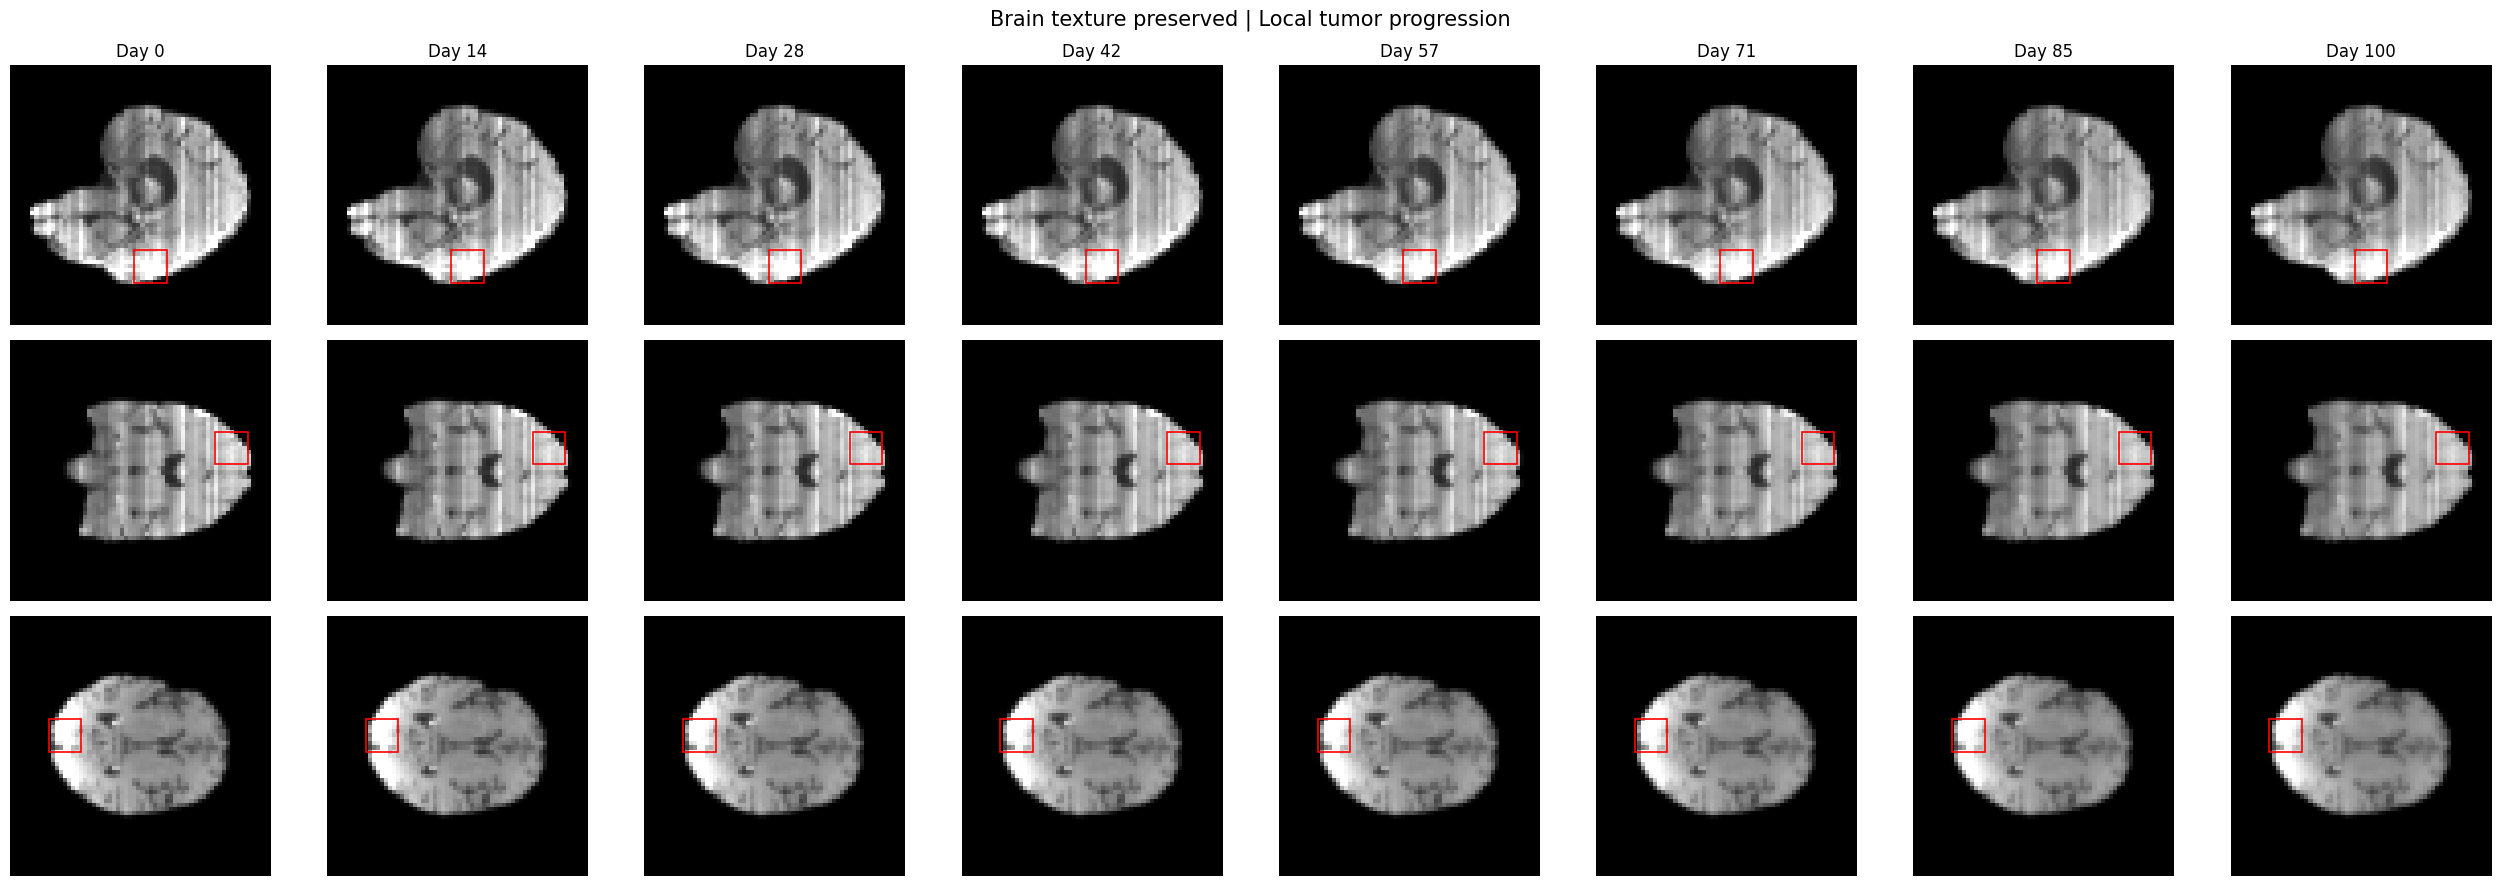

真实病例去噪与结构保持自检通过


In [14]:
# 真实测试病例：四分类识别 + 未来扩散预测
PREDICT_DAYS = 100  # 只需修改这里，例如改成 10 即生成 Day 0 到 Day 10
assert isinstance(PREDICT_DAYS, int) and PREDICT_DAYS >= 0

_real_case = TEST_ROOT / 'Mets_001'

# 分类是独立分支；没有真实标签/分类模型时只提示，不影响下面的扩散预测。
if CLASSIFIER_CHECKPOINT.exists():
    _classification_result = classify_tumor_case(_real_case)
else:
    print(
        '尚未输出肿瘤类型: 未找到四分类模型。请先准备 '
        f'{CLASSIFIER_LABEL_FILE.name}，再运行 train_tumor_classifier()。'
    )

# 原有未来肿瘤扩散预测功能保持不变。
_real_sequence, _real_metrics = predict_tumor_progression(
    _real_case,
    predict_delta_days=PREDICT_DAYS,
    change_strength=0.35,
)
print(f'真实病例推理输出: {tuple(_real_sequence.shape)} | 预测天数: {PREDICT_DAYS}')
print(
    f"轮廓 IoU: {_real_metrics['contour_iou']:.4f} | "
    f"纹理相关性: {_real_metrics['texture_correlation']:.4f} | "
    f"病变区均值变化: {_real_metrics['lesion_mean_change']:+.4f}"
)
assert tuple(_real_sequence.shape) == (PREDICT_DAYS + 1, 1, *IMG_SIZE)
assert torch.isfinite(_real_sequence).all()
assert _real_metrics['contour_iou'] > 0.95
assert _real_metrics['texture_correlation'] > 0.90
plot_full_progression(
    _real_sequence,
    days=list(range(PREDICT_DAYS + 1)),
    max_steps=min(8, PREDICT_DAYS + 1),
)
print('真实病例去噪与结构保持自检通过')